# **1. Lectura de señales EMG Y ECG y análisis del espectro de frecuencias**

por Luisa Fernanda Llamas Baldovino, Camila Montiel Zapata


In [ ]:
pip install neurokit2 hrv-analysis heartpy detectors matplotlib numpy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 616.8/616.8 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.7/225.7 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 4.6 MB/s eta 0:00:00


In [ ]:
pip install py-ecg-detectors

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.5/554.5 kB 9.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for gatspy: filename=gatspy-0.3-py3-none-any.whl size=43804 sha256=e0664361ff3ed2f1c3a16457d9bc947a9fa4d78bbd3e62606723e9b73065b78c
  Stored in directory: /root/.cache/pip/wheels/b5/56/88/04643e9be584a6018e10aae5789d98225995da3e89513c3f30
Successfully built gatspy


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.fft import fft, fftfreq
from scipy import signal
from scipy.signal import butter, filtfilt
import neurokit2 as nk

In [ ]:
ruta_ekg = r'/content/ekg.txt'
ekg = pd.read_csv(ruta_ekg, names=['Voltage'])
print(ekg.head())
print(len(ekg))

    Voltage
0  2.468231
1  2.468231
2  2.473118
3  2.468231
4  2.473118
1000


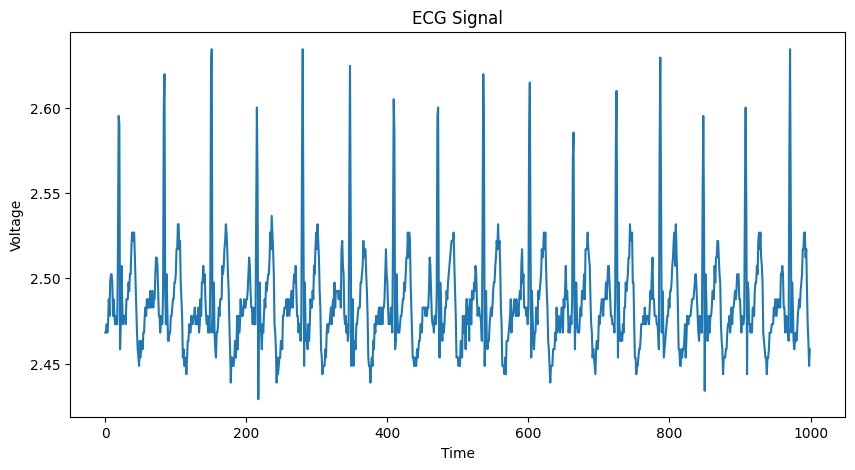

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(ekg['Voltage'])
plt.xlabel('Time')
plt.ylabel('Voltage')
plt.title('ECG Signal')
plt.show()

--- PICOS DETECTADOS EN EL RANGO (0.5 - 50 Hz) ---
Frecuencia: 1.60 Hz  |  Amplitud: 0.0104
Frecuencia: 3.10 Hz  |  Amplitud: 0.0069
Frecuencia: 4.70 Hz  |  Amplitud: 0.0090
Frecuencia: 6.20 Hz  |  Amplitud: 0.0071
Frecuencia: 8.20 Hz  |  Amplitud: 0.0054
Frecuencia: 9.80 Hz  |  Amplitud: 0.0063
Frecuencia: 10.60 Hz  |  Amplitud: 0.0033
Frecuencia: 11.40 Hz  |  Amplitud: 0.0027
Frecuencia: 12.20 Hz  |  Amplitud: 0.0027
Frecuencia: 13.00 Hz  |  Amplitud: 0.0023
Frecuencia: 14.60 Hz  |  Amplitud: 0.0026
Frecuencia: 15.90 Hz  |  Amplitud: 0.0022
Frecuencia: 16.80 Hz  |  Amplitud: 0.0033
Frecuencia: 18.00 Hz  |  Amplitud: 0.0029
Frecuencia: 19.60 Hz  |  Amplitud: 0.0029
Frecuencia: 21.20 Hz  |  Amplitud: 0.0037
Frecuencia: 22.80 Hz  |  Amplitud: 0.0033
Frecuencia: 23.90 Hz  |  Amplitud: 0.0026
Frecuencia: 25.00 Hz  |  Amplitud: 0.0029
Frecuencia: 26.10 Hz  |  Amplitud: 0.0024
Frecuencia: 27.60 Hz  |  Amplitud: 0.0021
Frecuencia: 29.20 Hz  |  Amplitud: 0.0024
Frecuencia: 30.80 Hz  |  Amplit

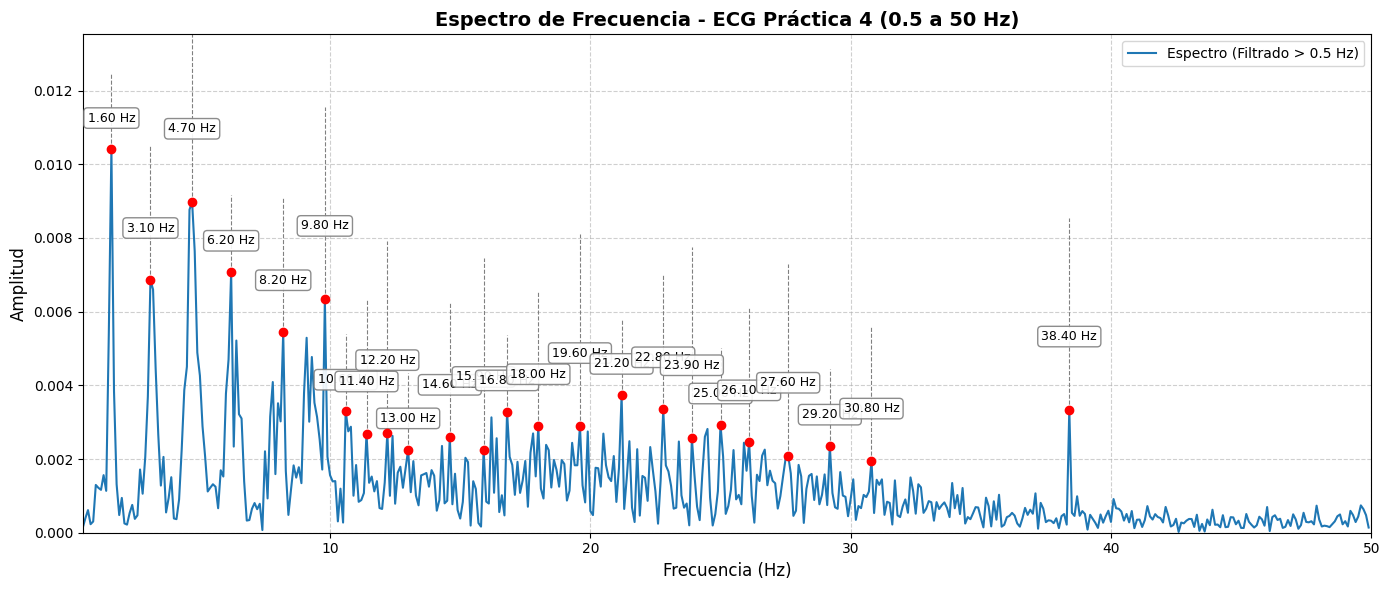

In [ ]:

# <--- Asegúrate de que este sea el tiempo total de tu gráfica
fs = 100
#t = np.linspace(0, tiempo_total, N, endpoint=False)

# ==========================================
# 2. FUNCIÓN DE ANÁLISIS DE ESPECTRO MEJORADA
# ==========================================
def analizar_espectro(senal_y, fs_val, nombre="Señal", zoom_max=40):
    n = len(senal_y)

    # Quitar nivel DC
    senal_y = senal_y - np.mean(senal_y)

    # ===== FFT =====
    fft_vals = fft(senal_y)
    freqs = fftfreq(n, 1/fs_val)[:n//2]
    espectro = 2.0/n * np.abs(fft_vals[:n//2])

    # ---> EL SECRETO PARA LA CLARIDAD <---
    # Enfocarnos solo en el rango útil del EKG (0.5 Hz a zoom_max)
    # Esto elimina el pico gigante de la respiración que aplasta tu gráfica
    rango_valido = (freqs >= 0.5) & (freqs <= zoom_max)
    freqs_util = freqs[rango_valido]
    espectro_util = espectro[rango_valido]

    # ===== DETECCIÓN DE PICOS =====
    # distance=5 evita que detecte picos basura que estén pegados
    # height establece el límite mínimo para considerar algo un pico
    umbral = np.max(espectro_util) * 0.15
    picos, _ = signal.find_peaks(espectro_util, height=umbral, distance=8)

    frec_picos = freqs_util[picos]
    amp_picos = espectro_util[picos]

    print(f"--- PICOS DETECTADOS EN EL RANGO (0.5 - {zoom_max} Hz) ---")

    # ===== GRÁFICO DEL ESPECTRO =====
    # Lienzo más ancho para que respiren los datos
    plt.figure(figsize=(14, 6))
    plt.plot(freqs_util, espectro_util, label='Espectro (Filtrado > 0.5 Hz)', linewidth=1.5, color='#1f77b4')

    # Añadir un poco de espacio en la parte superior para las etiquetas
    plt.ylim(0, np.max(espectro_util) * 1.3)

    for i, (f, a) in enumerate(zip(frec_picos, amp_picos)):
        print(f"Frecuencia: {f:.2f} Hz  |  Amplitud: {a:.4f}")

        # Lógica para alternar las alturas de las etiquetas y que no choquen
        dy = 20 + (i % 3) * 15
        dx = 0

        # Punto sobre el pico
        plt.scatter(f, a, color='red', zorder=5)

        # Línea punteada
        plt.plot([f, f], [a, a + (np.max(espectro_util) * (dy/100))], color='gray', linestyle='--', linewidth=0.8)

        # Etiqueta
        plt.annotate(f"{f:.2f} Hz", (f, a),
                     xytext=(dx, dy), textcoords="offset points",
                     fontsize=9, ha='center',
                     bbox=dict(facecolor='white', edgecolor='gray', alpha=0.9, boxstyle='round,pad=0.3'))

    plt.title(f"Espectro de Frecuencia - {nombre} (0.5 a {zoom_max} Hz)", fontsize=14, fontweight='bold')
    plt.xlabel("Frecuencia (Hz)", fontsize=12)
    plt.ylabel("Amplitud", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlim(0.5, zoom_max)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ==========================================
# 3. EJECUCIÓN
# ==========================================
senal = ekg['Voltage'].values
analizar_espectro(senal, fs, "ECG Práctica 4", zoom_max=50)

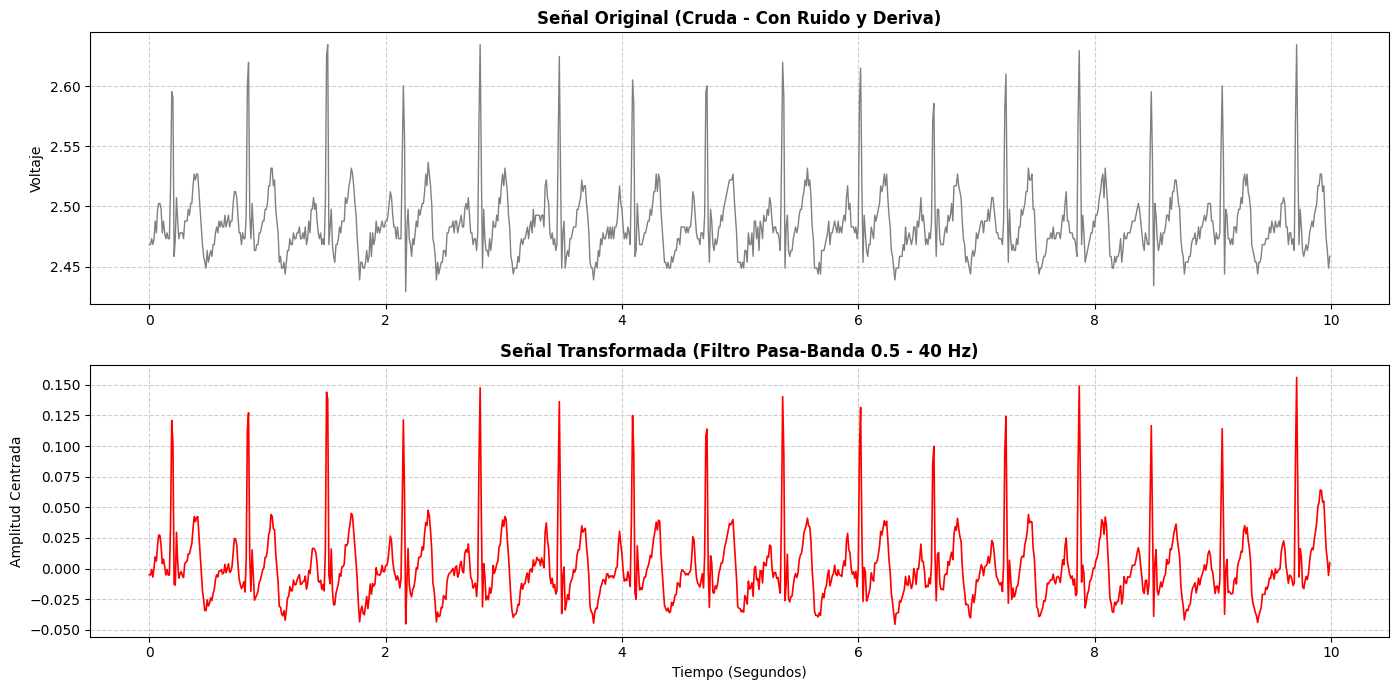

In [ ]:


fs = 100
N = len(ekg)
t = np.arange(N) / fs

# 2. FUNCIÓN DE TRANSFORMACIÓN (FILTRO PASA-BANDA)
def filtro_pasa_banda(senal, fs_val, lowcut=0.5, highcut=40.0, orden=2):
    nyquist = 0.5 * fs_val
    low = lowcut / nyquist
    high = highcut / nyquist

    # Diseño del filtro Butterworth Pasa-banda
    b, a = butter(orden, [low, high], btype='band')

    # filtfilt evita que la señal se desfase en el tiempo
    senal_filtrada = filtfilt(b, a, senal)
    return senal_filtrada

# 3. Aplicar la transformación
senal_original = ekg['Voltage'].values # Corregido: Extraer la columna 'Voltage' como un array de NumPy

senal_limpia = filtro_pasa_banda(senal_original , fs)

# (Opcional) Si ves que tus picos apuntan hacia abajo, descomenta esta línea:
# senal_limpia = senal_limpia * -1

# 4. GRÁFICA COMPARATIVA
plt.figure(figsize=(14, 7))

# Gráfica Original
plt.subplot(2, 1, 1)
plt.plot(t, senal_original, color='gray', linewidth=1)
plt.title('Señal Original (Cruda - Con Ruido y Deriva)', fontsize=12, fontweight='bold')
plt.ylabel('Voltaje')
plt.grid(True, linestyle='--', alpha=0.6)


# Gráfica Transformada
plt.subplot(2, 1, 2)
plt.plot(t, senal_limpia, color='red', linewidth=1.2)
plt.title('Señal Transformada (Filtro Pasa-Banda 0.5 - 40 Hz)', fontsize=12, fontweight='bold')
plt.xlabel('Tiempo (Segundos)')
plt.ylabel('Amplitud Centrada')
plt.grid(True, linestyle='--', alpha=0.6)


plt.tight_layout()
plt.show()

# 2 Análisis de la Variabilidad de la frecuencia cardíaca (HRV)


**2.1 NeuroKit y Detectors**



--- RESULTADOS DE LA DETECCIÓN ---
Total de latidos detectados: 15
Frecuencia Cardíaca Promedio: 94.8 BPM
Intervalos RR (segundos): [0.66 0.65 0.65 0.67 0.62 0.62 0.65 0.66 0.62 0.61 0.62 0.61 0.6  0.63]


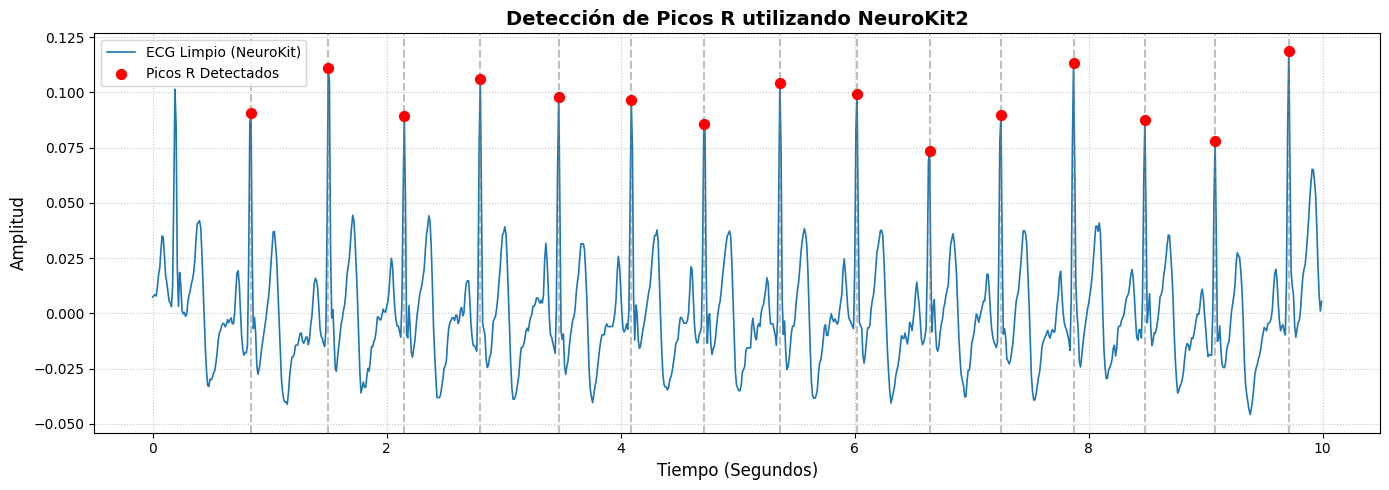

In [ ]:

senal_limpia = nk.ecg_clean(senal_original, sampling_rate=fs, method="neurokit")


_, info = nk.ecg_peaks(senal_limpia, sampling_rate=fs, method="neurokit")


indices_r = info["ECG_R_Peaks"]


tiempos_r = t[indices_r]
amplitudes_r = senal_limpia[indices_r]


rr_intervalos = np.diff(tiempos_r)

bpm = 60 / rr_intervalos
bpm_promedio = np.mean(bpm)

print("--- RESULTADOS DE LA DETECCIÓN ---")
print(f"Total de latidos detectados: {len(indices_r)}")
print(f"Frecuencia Cardíaca Promedio: {bpm_promedio:.1f} BPM")
print("Intervalos RR (segundos):", np.round(rr_intervalos, 3))


plt.figure(figsize=(14, 5))


plt.plot(t, senal_limpia, color='#1f77b4', linewidth=1.2, label='ECG Limpio (NeuroKit)')


plt.scatter(tiempos_r, amplitudes_r, color='red', s=50, zorder=5, label='Picos R Detectados')

for tr in tiempos_r:
    plt.axvline(x=tr, color='gray', linestyle='--', alpha=0.5)

plt.title('Detección de Picos R utilizando NeuroKit2', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo (Segundos)', fontsize=12)
plt.ylabel('Amplitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


--- RESULTADOS DETECTORS ---
Total de latidos detectados: 16
Frecuencia Cardíaca Promedio: 98.5 BPM
Intervalos RR (segundos): [0.43 0.67 0.65 0.71 0.56 0.67 0.61 0.66 0.65 0.61 0.62 0.58 0.65 0.6
 0.59]


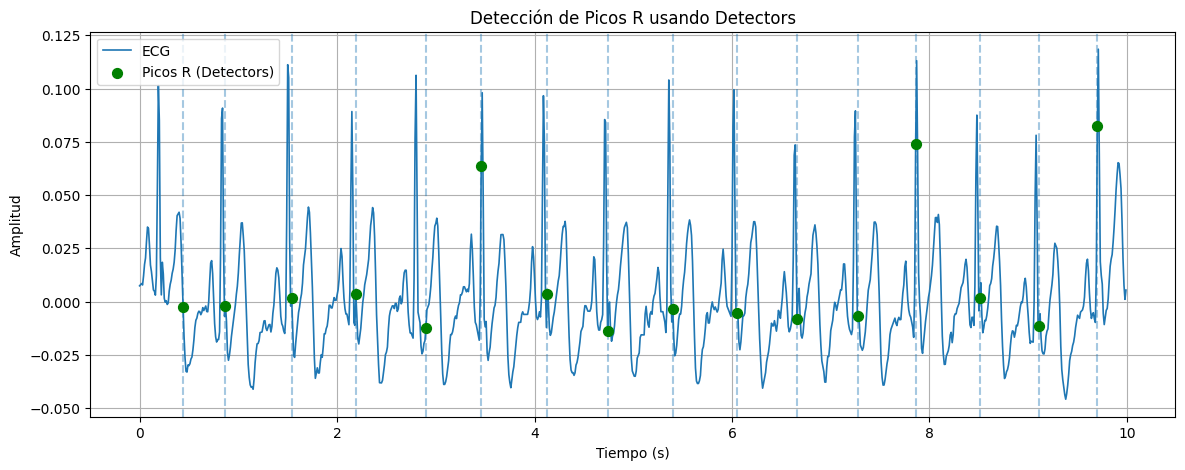

In [ ]:
from ecgdetectors import Detectors

# ==========================================
# DETECCIÓN CON DETECTORS
# ==========================================

# Creamos el objeto detector con la frecuencia de muestreo
detectors = Detectors(fs)

# IMPORTANTE: Detectors trabaja mejor con la señal original o ligeramente filtrada
# Puedes usar la señal original o la limpia (prueba ambas si quieres comparar)
senal_para_detectar = senal_limpia   # también puedes probar: senal_original

# Aplicamos un algoritmo de detección
# Opciones: pan_tompkins_detector, hamilton_detector, christov_detector, etc.
indices_r_det = detectors.pan_tompkins_detector(senal_para_detectar)

# Convertimos a tiempo
tiempos_r_det = t[indices_r_det]
amplitudes_r_det = senal_para_detectar[indices_r_det]

# ==========================================
# CÁLCULO DE HRV
# ==========================================

rr_intervalos_det = np.diff(tiempos_r_det)
bpm_det = 60 / rr_intervalos_det
bpm_promedio_det = np.mean(bpm_det)

print("\n--- RESULTADOS DETECTORS ---")
print(f"Total de latidos detectados: {len(indices_r_det)}")
print(f"Frecuencia Cardíaca Promedio: {bpm_promedio_det:.1f} BPM")
print("Intervalos RR (segundos):", np.round(rr_intervalos_det, 3))

# ==========================================
# GRÁFICA
# ==========================================

plt.figure(figsize=(14, 5))

plt.plot(t, senal_para_detectar, linewidth=1.2, label='ECG')

plt.scatter(tiempos_r_det, amplitudes_r_det,
            color='green', s=50, zorder=5, label='Picos R (Detectors)')

for tr in tiempos_r_det:
    plt.axvline(x=tr, linestyle='--', alpha=0.4)

plt.title('Detección de Picos R usando Detectors')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.show()

**2.2 Calcular la variabilidad de la frecuencia cardíaca (HRV) a partir de los picos R detectados**

In [ ]:

senal_limpia = nk.ecg_clean(senal_original, sampling_rate=fs)


_, info = nk.ecg_peaks(senal_limpia, sampling_rate=fs)
indices_r = info["ECG_R_Peaks"]




tiempos_r = indices_r / fs

rr_intervalos = np.diff(tiempos_r)



print("\n--- INTERVALOS RR (en segundos) ---")

for i, rr in enumerate(rr_intervalos):
    print(f"RR[{i}] = {rr:.3f} s")

# Frecuencia cardíaca
bpm = 60 / rr_intervalos
bpm_promedio = np.mean(bpm)

print(f"\nFrecuencia Cardíaca Promedio: {bpm_promedio:.2f} BPM")
# SDNN (desviación estándar)
sdnn = np.std(rr_intervalos)

# Varianza
varianza = np.var(rr_intervalos)

print(f"SDNN (Desviación estándar): {sdnn:.4f} s")
print(f"Varianza: {varianza:.6f} s^2")


--- INTERVALOS RR (en segundos) ---
RR[0] = 0.660 s
RR[1] = 0.650 s
RR[2] = 0.650 s
RR[3] = 0.670 s
RR[4] = 0.620 s
RR[5] = 0.620 s
RR[6] = 0.650 s
RR[7] = 0.660 s
RR[8] = 0.620 s
RR[9] = 0.610 s
RR[10] = 0.620 s
RR[11] = 0.610 s
RR[12] = 0.600 s
RR[13] = 0.630 s

Frecuencia Cardíaca Promedio: 94.81 BPM
SDNN (Desviación estándar): 0.0216 s
Varianza: 0.000466 s^2


**2.3 Investigar e implementar las siguientefuncion de la librería hrvanalysis para extraer características de HRV en el dominio del tiempo: get_time_domain_features**

In [ ]:
from hrvanalysis import get_time_domain_features, get_frequency_domain_features, get_geometrical_features

In [ ]:
# EXTRAER LOS PIKOS R Y FRECUENCIA DE MUESTREO
picos_r = info['ECG_R_Peaks']  # Esto es el array de picos
fs = info['sampling_rate']     # Esto es 100 Hz

print(f"Picos R extraídos: {picos_r}")
print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Número de picos R: {len(picos_r)}")

# 1. CALCULAR INTERVALOS RR EN MILISEGUNDOS
intervalos_rr_muestras = np.diff(picos_r)  # Diferencia en muestras
intervalos_rr_ms = (intervalos_rr_muestras / fs) * 1000  # Convertir a ms

print(f"\n=== CÁLCULO DE HRV ===")
print(f"Intervalos RR: {intervalos_rr_ms} ms")

# 2. CALCULAR HRV - VARIABILIDAD BÁSICA
hrv_std = np.std(intervalos_rr_ms)  # SDNN - Variabilidad total
hrv_mean = np.mean(intervalos_rr_ms)  # Promedio de intervalos
fc_promedio = 60000 / hrv_mean  # FC en lpm

print(f"\n--- RESULTADOS HRV ---")
print(f"HRV (SDNN): {hrv_std:.2f} ms")
print(f"Intervalo RR promedio: {hrv_mean:.2f} ms")
print(f"FC promedio: {fc_promedio:.1f} lpm")

# 3. MÉTRICAS ADICIONALES
if len(intervalos_rr_ms) >= 2:
    diferencias_rr = np.diff(intervalos_rr_ms)
    rmssd = np.sqrt(np.mean(diferencias_rr ** 2))  # Variabilidad corto plazo
    nn50 = np.sum(np.abs(diferencias_rr) > 50)
    pnn50 = (nn50 / len(diferencias_rr)) * 100

    print(f"HRV (RMSSD): {rmssd:.2f} ms")
    print(f"pNN50: {pnn50:.1f} %")
    print(f"Número de intervalos analizados: {len(intervalos_rr_ms)}")

Picos R extraídos: [ 84 150 215 280 347 409 471 536 602 664 725 787 848 908 971]
Frecuencia de muestreo: 100 Hz
Número de picos R: 15

=== CÁLCULO DE HRV ===
Intervalos RR: [660. 650. 650. 670. 620. 620. 650. 660. 620. 610. 620. 610. 600. 630.] ms

--- RESULTADOS HRV ---
HRV (SDNN): 21.58 ms
Intervalo RR promedio: 633.57 ms
FC promedio: 94.7 lpm
HRV (RMSSD): 23.04 ms
pNN50: 0.0 %
Número de intervalos analizados: 14
